<a href="https://colab.research.google.com/github/okana2ki/multiV/blob/main/kmeans_SSDSE_C2_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 機械学習帳：[非階層的クラスタリング](https://colab.research.google.com/github/chokkan/mlnote/blob/main/unsupervised/01kmeans.ipynb) より

## 確認問題

[教育用標準データセット（SSDSE）](https://www.nstac.go.jp/SSDSE/)に収録されている都道府県庁所在市別・家計消費データ（SSDSE-C）に対してクラスタ分析を適用し、消費行動が類似している都道府県のクラスタを作りたい。

### (1) データセットの読み込み

このデータセットを読み込み、各都道府県庁所在地を特徴ベクトルで表現せよ。

In [1]:
# prompt: https://www.nstac.go.jp/sys/files/SSDSE-C-2025.csv を読み込み、先頭5行を表示

import pandas as pd

url = 'https://www.nstac.go.jp/sys/files/SSDSE-C-2025.csv'
df = pd.read_csv(url, encoding='shift_jis')

print(df.head())


  SSDSE-C-2025 2022-2024年 City  LA03     LB00   LB01 LB011001 LB012001  \
0        地域コード       都道府県    市  世帯人員   食料（合計）  01　穀類        米      食パン   
1       R00000         全国   全国  2.90  1033514  82646    22473    10497   
2       R01100        北海道  札幌市  2.75   961122  81381    26176     9351   
3       R02201        青森県  青森市  2.82   975027  79647    22001     9159   
4       R03201        岩手県  盛岡市  2.94  1015868  82555    23670     8671   

  LB012002 LB013001  ... LB121104 LB121105 LB121106 LB121107 LB121108  \
0     他のパン  生うどん・そば  ...   すし（外食）       和食      中華食       洋食       焼肉   
1    23163     3687  ...    15325    24196     4683    11834     7779   
2    20249     3268  ...    18520    21172     3374    15181     7392   
3    19637     3575  ...    13481    16350     2798     8643     7417   
4    20732     3560  ...    14340    12698     2281     6726     8090   

  LB121109 LB121110 LB121201 LB121202 LB122001  
0   ハンバーガー  他の主食的外食      喫茶代      飲酒代     学校給食  
1     6024    5072

↓より見やすく表示

In [2]:
df.head()

,SSDSE-C-2025,2022-2024年,City,LA03,LB00,LB01,LB011001,LB012001,LB012002,LB013001,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
0,地域コード,都道府県,市,世帯人員,食料（合計）,01 穀類,米,食パン,他のパン,生うどん・そば,...,すし（外食）,和食,中華食,洋食,焼肉,ハンバーガー,他の主食的外食,喫茶代,飲酒代,学校給食
1,R00000,全国,全国,2.90,1033514,82646,22473,10497,23163,3687,...,15325,24196,4683,11834,7779,6024,50727,8829,14603,8562
2,R01100,北海道,札幌市,2.75,961122,81381,26176,9351,20249,3268,...,18520,21172,3374,15181,7392,4133,26879,6163,15706,11924
3,R02201,青森県,青森市,2.82,975027,79647,22001,9159,19637,3575,...,13481,16350,2798,8643,7417,4390,18536,3815,9465,4784
4,R03201,岩手県,盛岡市,2.94,1015868,82555,23670,8671,20732,3560,...,14340,12698,2281,6726,8090,4399,37322,5635,15130,11412


* ダウンロードしてきたファイルを読み込んでもよいのですが、今回は、サイトから直接ファイルを読み込むことにしました。
* いきなり、特徴ベクトル表現をしてもよいのですが、**まず、読み込むだけ**、というように**小分けに指示**して、**内容を確認しながら**進むことにしました。**複雑なプログラムを作るときは、段階を踏んで作っていく方がお勧め**です。（AIの能力が急速に高まりつつあるので、複雑なプログラムを一気に作れるようになる方向にはありますが）
* 今回のような依頼の仕方をすると、shift_jisであることは、AIが適切に判断してくれることが多いようです。shift_jisで読み込まなかった場合は、エラーが出ますが、エラーをAIに説明してもらったり対処してもらうのは容易でしょう。
* **ここで読み込んだ内容を確認しておく**と、この後、特徴ベクトルを抽出したときに、うまくできているかの確認が容易です。




In [3]:
# prompt: 各都道府県庁所在地（2行目以降）を特徴ベクトル（4列目以降）で表現し、先頭5行を表示

# 各都道府県庁所在地（2行目以降）を特徴ベクトル（4列目以降）で表現
df_features = df.iloc[2:, 4:]

# 先頭5行を表示
df_features.head()


,LB00,LB01,LB011001,LB012001,LB012002,LB013001,LB013002,LB013003,LB013004,LB013005,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
2,961122,81381,26176,9351,20249,3268,2139,1446,4417,5954,...,18520,21172,3374,15181,7392,4133,26879,6163,15706,11924
3,975027,79647,22001,9159,19637,3575,2490,1292,6053,8012,...,13481,16350,2798,8643,7417,4390,18536,3815,9465,4784
4,1015868,82555,23670,8671,20732,3560,2686,1357,6628,7286,...,14340,12698,2281,6726,8090,4399,37322,5635,15130,11412
5,1039185,80348,19877,10061,22520,3367,2049,1526,5132,7210,...,15983,25161,3638,13788,7206,5797,26803,8958,17251,10989
6,984222,74567,19327,8095,18393,3674,4022,1287,5735,6647,...,15221,16792,1795,6919,7613,3703,24842,4563,12695,12171


* **2行目以降という指示**なしに自動で判断させることは難しいようでした。1行目の全国を除こうと思ったので、こうしました。なお、0行目から始まるので、その数え方で指示しましたが、1行目から始まる数え方で指示してもAIが判断してくれることもあると思います。
* **4列目以降**というのを指示なしで自動判断するのも難しいようです。食料（合計）の列以降、というつもりです。「消費行動の類似性でクラスタリングせよ」というお題なので、「世帯人員」列を除くのは妥当だと思います。「食料（合計）」は、それ以降の列の合計なので、冗長な特徴になっていると思われるので、これも除くという考えもあると思います。また、「穀類」のような小計の列もあり、これも除いた方がよいかもしれませんが、どの列を除くかの指示が面倒かなと思い、小計も合計も含まれたままにしました。（実は、これが後で問題になります）（後で紹介しますが、実は、ある方法を使うと、小計や合計の列は簡単に除くことができます）
* 丁寧に分析するなら、「世帯人員」で、各品目の支出額を正規化するという分析が望ましいかもしれませんが、今回はそれはしていません。各品目の支出額は一世帯当たりで集計されているので、それで正規化した方が消費の特徴を表しているとも言えるし、世帯人数の多少も含めて支出額の特徴を捉えるという考えもあると思います。
* 各品目の支出額は一世帯当たりで集計されている、というようなことは、[SSDSEのHP](https://www.nstac.go.jp/use/literacy/ssdse/)の[**データごとの解説資料**](https://www.nstac.go.jp/sys/files/kaisetsu-C-2025.pdf)に書いてあります。**適切な分析のためには、分析前に解説に目を通しておくことが必要**ですね。
* ここで**抽出した結果を表示して、意図通りにできていることを確認**して、次に進みます。
* 元のデータの0行目の品目名や、2列目の都市名がdf_featuresには含まれておらず、分かりにくくなっているのですが、必要になれば、後で回復できるだろうと思うので、ここはそのままにして進みます。

### (2) WCSSのプロット

K-meansクラスタリングを異なるクラスタ数$K$で実行し、横軸にクラスタ数、縦軸にK-meansの目的関数の値、すなわちクラスタ内平方和（WCSS: within-cluster sum-of-squares）をプロットしたグラフを描画せよ。

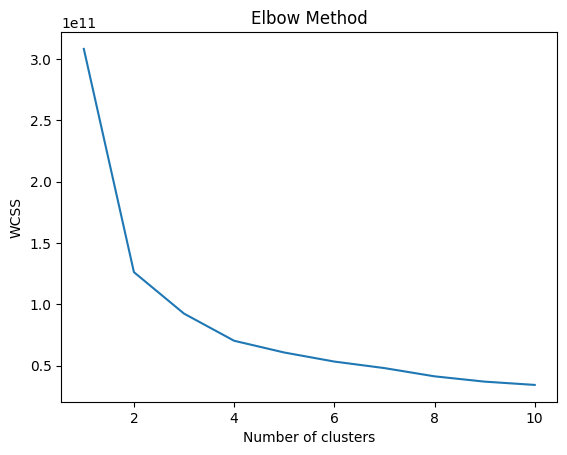

In [4]:
# prompt: K-meansクラスタリングを異なるクラスタ数 K で実行し、横軸にクラスタ数、縦軸にK-meansの目的関数の値、すなわちクラスタ内平方和（WCSS: within-cluster sum-of-squares）をプロットしたグラフを描画せよ。

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# クラスタ数の上限
max_clusters = 10

# クラスタ数ごとのWCSSを格納するリスト
wcss = []

# 異なるクラスタ数でK-meansクラスタリングを実行
for i in range(1, max_clusters + 1):
  kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)  # n_init: 初期化回数（何回試すか）を明示的に指定することで警告メッセージを回避
  kmeans.fit(df_features)

  # クラスタ内平方和（WCSS）をリストに追加
  wcss.append(kmeans.inertia_)

# クラスタ数とWCSSをプロット
plt.plot(range(1, max_clusters + 1), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


↑このグラフが何のことか分からない人は、[この資料](https://colab.research.google.com/github/chokkan/mlnote/blob/main/unsupervised/01kmeans.ipynb)の目次から「クラスタ数の選び方」を参照。

* 以上のように、問題文をそのままプロンプトに入力すると、うまくプログラミングできた！と一瞬喜んでしまうかもしれませんが、ここで、落ち着いて、データを見直してみましょう。
* すると、**品目によって、支出額の多少に開きがある**のはもちろん、小計や合計もあるので、**特に一番大きい「食料（合計）」という特徴量が大きく効いて**、**ほぼ「食料（合計）」の多少だけでクラスタリングが決まってしまっているのではないか**と想像できます。
* これでは、題意であった「消費行動の類似性」によりクラスタリングしたことにはなっていませんよね。ほぼ合計額だけを考慮してクラスタリングしたことになってしまっていると思います。
* このような結果になってしまっていることをちゃんとデータで確認するには、このまま次の(3)に進んで、各クラスタに属する都市名を洗い出すか、または、クラスタごとの「食料（合計）」の箱ひげ図を描くと、確認できると思います。ぜひ、この確認にチャレンジしてみて下さい。**←今日の宿題その１**

* さて、この「大きな値の特徴量にクラスタリング結果が左右されてしまう」という問題は、どう対処したらよいでしょうか？
* まずやるべきことは、**小計や合計をデータから除く**ことです。**←今日の宿題その２。**これは「消費行動の類似性」によりクラスタリングするという目的から考えると、必要な操作だと思います。ただ、ちょっと、除くための指示が面倒そうに思うかもしれません。
* 合計や小計をデータから除くのは、個別にこの列を除けと指示しなくても、一括指示することができそうです。どうしてかというと、一番上の行（各列の識別記号）を見ると、合計や小計は、LB00やLB01のような短かいコードが割り振られているからです。AIと相談すると具体的にどうすればよいかを教えてくれると思います。さらにいうと、データの形式を説明するPDFファイルを添付してAIに頼むとより確実にやりたいことが伝わります。なお、ただし、合計や小計も特徴量だと捉えてクラスタリングするという考えもありかなとも思います。
* 続いてやるべきことは、**データを前処理してから、クラスタリング**を行うことです。この前処理は、上記にしたがって、個別の品目の支出額だけを残したデータとした場合も、それらの支出額の間に大き目の開きがあるので、有効に働くと思いますし、合計や小計を残したまま分析するきは必須となります。
* どのような前処理をするとよいか、ぜひ考えて、それを実行してみて下さい。その後、クラスタリングを実行して、結果を前処理しなかった場合と比べて下さい。**←今日の宿題その３**。AIに質問しても、おそらく正しい前処理を教えてくれると思います。

* 前処理のヒントを書いておくと、「標準化」です。「標準化」と「正規化」については、[ここ](https://qiita.com/oki_kosuke/items/02ec7bee92c85cf10ac2)を参照して内容やそれをする理由を理解してから、プログラムを書いて実行して下さい。キーワードだけ聞いて、AIにプログラムを頼んでおしまい、では力がつきません。AIに理由とかも尋ねながらプログラミングするという勉強スタイルであれば、それでいいのですが。

### (3) K-meansクラスタリング

(2)の結果に基づき、クラスタ数$K$を適当に選び、K-meansクラスタリングを実行せよ。$1$から$K$までの各クラスタに対して、それぞれ所属する都道府県庁所在地を明らかにせよ。**←今日の宿題その４**

# 演習問題：階層的クラスタリング（今日の宿題その５）

以上のデータ（合計や小計を除いて、標準化したもの）を、階層的クラスタリングしなさい（デンドログラムを書きなさい）

# 宿題その１：クラスタごとの箱ひげ図

<Figure size 1000x600 with 0 Axes>

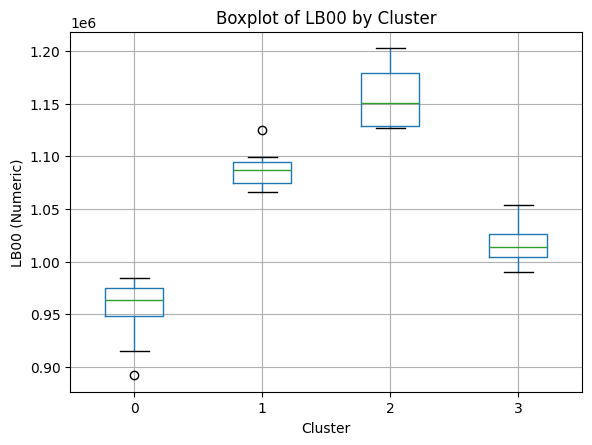

In [5]:
# prompt: df_featuresに対して、クラスタ数4でK-meansクラスタリングを実行し、クラスタごとの”LB00”（数値に変換したもの）の箱ひげ図を書いて下さい。

# クラスタ数を選択（例として4）
n_clusters = 4

# K-meansクラスタリングを実行
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
clusters = kmeans.fit_predict(df_features)

# クラスタラベルを元のデータフレームに追加
df_clustered = df.iloc[2:].copy()
df_clustered['cluster'] = clusters

# LB00列を数値に変換
# 元のデータフレームの列名を確認し、必要であれば修正
df_clustered['LB00_numeric'] = pd.to_numeric(df_clustered['LB00'], errors='coerce')

# クラスタごとのLB00（数値）の箱ひげ図を作成
plt.figure(figsize=(10, 6))
df_clustered.boxplot(column='LB00_numeric', by='cluster')
plt.title('Boxplot of LB00 by Cluster')
plt.xlabel('Cluster')
plt.ylabel('LB00 (Numeric)')
plt.suptitle('') # Matplotlibのバグ対策で自動生成されるタイトルを削除
plt.show()


上の箱ひげ図を見ると、**予想通り、食料（合計）の値によってクラスタリングされた（他の特徴量はほぼ無関係であった）**ことが確認できる。

# 宿題その２：小計や合計を除いて特徴ベクトルを抽出（添付ファイルを使ってGeminiとの対話でコーディング）

操作手順：

1. 画面左端のフォルダアイコンをクリックして、ファイル表示カラムを開き、そこに、「[SSDSE-家計消費 の解説](https://www.nstac.go.jp/sys/files/kaisetsu-C-2025.pdf)」pdfファイル(kaisetsu-C-2025.pdf)をドラッグアンドドロップ
2. ファイル表示カラム中のkaisetsu-C-2025.pdfにマウスオンし、現れたGemini（Geminiに追加）アイコンをクリック
3. AIに依頼する内容を入力

## 対話内容

夏樹：  
https://www.nstac.go.jp/sys/files/SSDSE-C-2025.csv を読み込み、各都道府県庁所在地を特徴ベクトルで表現する。添付ファイルにデータの解説があるのでそれを参照してデータのどの部分を特徴ベクトルとするかを決める。  
添付したファイルは「[SSDSE-家計消費 の解説](https://www.nstac.go.jp/sys/files/kaisetsu-C-2025.pdf)」です。

Gemini:  
承知いたしました。CSVファイルを読み込み、添付された解説資料を参照して特徴ベクトルを抽出するコードを生成するための計画を作成します。
- データファイルの読み込み: 指定されたURLからCSVファイルをpandas DataFrameとして読み込みます。
- 解説資料の確認: 添付された解説資料PDFの内容を確認し、特徴量として使用すべき列を特定します。特に、消費行動に関連する個別の品目支出の列を特定します。
- 特徴量の抽出: 特定した列をDataFrameから抽出し、各都道府県庁所在地を特徴ベクトルとして表現します。
- 結果の表示: 抽出した特徴ベクトルの最初の数行を表示して、正しく抽出できたことを確認します。
- Finish task: 特徴ベクトル抽出のコードを提示し、次のステップ（クラスタリングなど）に進む準備ができたことをユーザーに伝えます。

生成しています…  
- Preparing
- データファイルの読み込み
- 解説資料の確認
- 特徴量の抽出
- 結果の表示
- Finish task

## ↓以下は、Geminiの出力です：

# Task
URL "https://www.nstac.go.jp/sys/files/SSDSE-C-2025.csv" のCSVデータを読み込み、添付ファイル "/content/kaisetsu-C-2025.pdf" を参照して、各都道府県庁所在地の消費行動に関する個別の品目支出を特徴ベクトルとして抽出し、その結果を表示してください。

## データファイルの読み込み

### Subtask:
指定されたURLからCSVファイルをpandas DataFrameとして読み込みます。


**Reasoning**:
The first step is to load the data from the provided URL into a pandas DataFrame, as instructed, using the specified encoding and variable name, then display the head to verify.



In [7]:
import pandas as pd

url = 'https://www.nstac.go.jp/sys/files/SSDSE-C-2025.csv'
df_original = pd.read_csv(url, encoding='shift_jis')
display(df_original.head())

,SSDSE-C-2025,2022-2024年,City,LA03,LB00,LB01,LB011001,LB012001,LB012002,LB013001,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
0,地域コード,都道府県,市,世帯人員,食料（合計）,01 穀類,米,食パン,他のパン,生うどん・そば,...,すし（外食）,和食,中華食,洋食,焼肉,ハンバーガー,他の主食的外食,喫茶代,飲酒代,学校給食
1,R00000,全国,全国,2.90,1033514,82646,22473,10497,23163,3687,...,15325,24196,4683,11834,7779,6024,50727,8829,14603,8562
2,R01100,北海道,札幌市,2.75,961122,81381,26176,9351,20249,3268,...,18520,21172,3374,15181,7392,4133,26879,6163,15706,11924
3,R02201,青森県,青森市,2.82,975027,79647,22001,9159,19637,3575,...,13481,16350,2798,8643,7417,4390,18536,3815,9465,4784
4,R03201,岩手県,盛岡市,2.94,1015868,82555,23670,8671,20732,3560,...,14340,12698,2281,6726,8090,4399,37322,5635,15130,11412


## 特徴量の抽出

### Subtask:
解説資料を参照し、都道府県庁所在地（2行目以降）の消費に関するデータ（4列目以降）を特徴ベクトルとする。世帯人員（LA03）は消費行動の特徴とは考えにくいので除外する。小計や合計の列も除外する（'LB00', 'LB01' など）。具体的には、解説資料P.3の「統計調査項目一覧」を参照し、個別の品目の支出に該当する列を選択する。列名が'LB'で始まり、かつ末尾が4桁の数字である列が個別の品目支出に該当すると判断しました。


**Reasoning**:
Extract the relevant feature columns from the original DataFrame based on the column naming convention and the provided data description, then remove the header and aggregate rows, and finally display the head of the resulting DataFrame.



In [8]:
# 特徴量となる列を抽出
# 列名が 'LB' で始まり、かつ末尾が4桁の数字である列を選択
feature_columns = [col for col in df_original.columns if col.startswith('LB') and col[-4:].isdigit()]
features_df = df_original.loc[:, feature_columns]

# 都道府県庁所在地のデータ（最初の行は項目名、2行目は全国の合計なので除く）
features_df = features_df.iloc[2:]

# 結果の先頭5行を表示
display(features_df.head())

,LB011001,LB012001,LB012002,LB013001,LB013002,LB013003,LB013004,LB013005,LB013006,LB013007,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
2,26176,9351,20249,3268,2139,1446,4417,5954,2120,628,...,18520,21172,3374,15181,7392,4133,26879,6163,15706,11924
3,22001,9159,19637,3575,2490,1292,6053,8012,2501,548,...,13481,16350,2798,8643,7417,4390,18536,3815,9465,4784
4,23670,8671,20732,3560,2686,1357,6628,7286,2242,840,...,14340,12698,2281,6726,8090,4399,37322,5635,15130,11412
5,19877,10061,22520,3367,2049,1526,5132,7210,2014,763,...,15983,25161,3638,13788,7206,5797,26803,8958,17251,10989
6,19327,8095,18393,3674,4022,1287,5735,6647,2087,588,...,15221,16792,1795,6919,7613,3703,24842,4563,12695,12171


## 解説資料の確認

### Subtask:
添付された解説資料PDFの内容を確認し、特徴量として使用すべき列を特定します。特に、消費行動に関連する個別の品目支出の列を特定します。


## 特徴量の抽出

### Subtask:
解説資料を参照し、都道府県庁所在地（2行目以降）の消費に関するデータ（4列目以降）を特徴ベクトルとする。世帯人員（LA03）は消費行動の特徴とは考えにくいので除外する。小計や合計の列も除外する（'LB00', 'LB01' など）。具体的には、解説資料P.3の「統計調査項目一覧」を参照し、個別の品目の支出に該当する列を選択する。列名が'LB'で始まり、かつ末尾が4桁の数字である列が個別の品目支出に該当すると判断しました。


## Summary:

### Data Analysis Key Findings

*   The raw data from the provided URL was successfully loaded into a pandas DataFrame using `shift_jis` encoding.
*   Features representing individual consumption expenditures for prefectural capitals were extracted based on column names starting with 'LB' and ending with a four-digit number, excluding the first two rows (header and national total).
*   The resulting DataFrame `features_df` contains the extracted features for each prefectural capital.

### Insights or Next Steps

*   The extracted `features_df` can now be used for further analysis, such as clustering or dimensionality reduction, to identify patterns in consumption behavior across prefectural capitals.
*   Consider exploring the relationships between different expenditure categories to gain deeper insights into regional spending habits.


# 宿題その３：（合計や小計を除いた特徴ベクトルを）標準化してクラスタリングし、WCSSをプロット

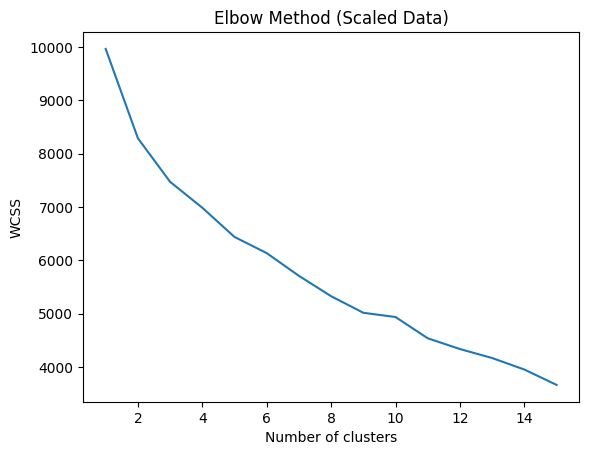

In [10]:
# prompt: まずfeatures_dfの各特徴量を標準化して下さい。それに続いて、K-meansクラスタリングを異なるクラスタ数 K で実行し、横軸にクラスタ数、縦軸にK-meansの目的関数の値、すなわちクラスタ内平方和（WCSS: within-cluster sum-of-squares）をプロットしたグラフを描画せよ。

from sklearn.preprocessing import StandardScaler

# features_dfの標準化
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_df)

# クラスタ数の上限
max_clusters = 15

# クラスタ数ごとのWCSSを格納するリスト
wcss = []

# 異なるクラスタ数でK-meansクラスタリングを実行
for i in range(1, max_clusters + 1):
  kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)
  kmeans.fit(features_scaled)

  # クラスタ内平方和（WCSS）をリストに追加
  wcss.append(kmeans.inertia_)

# クラスタ数とWCSSをプロット
plt.plot(range(1, max_clusters + 1), wcss)
plt.title('Elbow Method (Scaled Data)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# 宿題その４：各クラスタに属する都道府県庁所在地を表示

*  上のグラフから分かるように、**ひじの位置がはっきりしないので、これに基づいてKを選ぶのは難しい**のですが、以下では、K=3, 5, 9の３つの場合を調べています。
*  **都道府県庁所在地を書かせるところは一工夫必要**です。以下では、「**dfのCity列に記されている**」と教えています。この情報をAIが自分で見つけるのはおそらく難しいと思うので、このように人が助けてあげることが有効です。

In [13]:
# prompt: K=3, 5, 9のそれぞれに対して、K-meansクラスタリングを実行せよ。1 からKまでの各クラスタに対して、それぞれ所属する都道府県庁所在地を明らかにせよ。都道府県庁所在地は、dfのCity列に記されている。

# K-meansクラスタリングを実行し、各クラスタに所属する都道府県庁所在地を明らかにする関数
def perform_kmeans_and_list_cities(n_clusters, features, original_df):
    """
    K-meansクラスタリングを実行し、各クラスタに所属する都道府県庁所在地を表示する。

    Args:
        n_clusters (int): クラスタ数。
        features (numpy.ndarray): 特徴量データ。
        original_df (pd.DataFrame): 元のデータフレーム（City列を含む）。
    """
    print(f"\n--- クラスタ数 K = {n_clusters} ---")
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    clusters = kmeans.fit_predict(features)

    # 元のデータフレームにクラスタラベルを追加 (iloc[2:]で都道府県庁所在地行のみを対象)
    clustered_df = original_df.iloc[2:].copy()
    clustered_df['cluster'] = clusters

    # 各クラスタに所属する都市名を表示
    for i in range(n_clusters):
        print(f"クラスタ {i+1}:")
        cities_in_cluster = clustered_df[clustered_df['cluster'] == i]['City'].tolist()
        print(cities_in_cluster)

# K=3, 5, 9でK-meansクラスタリングを実行
for k in [3, 5, 9]:
    perform_kmeans_and_list_cities(k, features_scaled, df_original)


--- クラスタ数 K = 3 ---
クラスタ 1:
['福井市', '津市', '和歌山市', '鳥取市', '松江市', '岡山市', '広島市', '山口市', '徳島市', '高松市', '松山市', '高知市', '福岡市', '佐賀市', '長崎市', '熊本市', '大分市', '宮崎市', '鹿児島市', '那覇市']
クラスタ 2:
['水戸市', '宇都宮市', '前橋市', 'さいたま市', '千葉市', '東京都区部', '横浜市', '富山市', '金沢市', '甲府市', '岐阜市', '静岡市', '名古屋市', '大津市', '京都市', '大阪市', '神戸市', '奈良市']
クラスタ 3:
['札幌市', '青森市', '盛岡市', '仙台市', '秋田市', '山形市', '福島市', '新潟市', '長野市']

--- クラスタ数 K = 5 ---
クラスタ 1:
['那覇市']
クラスタ 2:
['水戸市', '宇都宮市', '前橋市', '甲府市', '長野市']
クラスタ 3:
['福井市', '津市', '和歌山市', '鳥取市', '松江市', '岡山市', '広島市', '山口市', '徳島市', '高松市', '松山市', '高知市', '福岡市', '佐賀市', '長崎市', '熊本市', '大分市', '宮崎市', '鹿児島市']
クラスタ 4:
['札幌市', '青森市', '盛岡市', '仙台市', '秋田市', '山形市', '福島市', '新潟市', '富山市']
クラスタ 5:
['さいたま市', '千葉市', '東京都区部', '横浜市', '金沢市', '岐阜市', '静岡市', '名古屋市', '大津市', '京都市', '大阪市', '神戸市', '奈良市']

--- クラスタ数 K = 9 ---
クラスタ 1:
['札幌市', '青森市', '盛岡市', '秋田市']
クラスタ 2:
['鳥取市', '松江市', '岡山市', '広島市', '山口市', '徳島市', '高松市', '高知市']
クラスタ 3:
['仙台市', '宇都宮市', 'さいたま市', '千葉市', '東京都区部', '横浜市', '静岡市']
クラスタ 4:
['福岡市', '佐賀市', '長崎市'

*  以上のように、各クラスタに所属している都市名を見ると、**近隣地域の都市がクラスタを形成していることが多く**、これはそれらの都市間で消費支出の傾向が似ていることを反映しているのだと思います。